# Age Classifier — B23BB1004
**Deep Learning Spring 2026 — Phase 2**

**Pipeline:** SSL Pre-training (SimCLR) → Supervised Fine-tuning (FocalLoss)

**Constraints:**
- ResNet-18 trained from scratch (`weights=None`)
- Image size: 224×224
- SSL backbone from our own dataset only
- Final model trained on train+val combined


## Cell 1 — Environment Setup + GPU Check

In [18]:
import torch, os, random, time, copy, warnings
import numpy as np
import pandas as pd
from PIL import Image
import matplotlib.pyplot as plt

import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, ConcatDataset
from torchvision import transforms, models

warnings.filterwarnings('ignore')

# ─── Configuration ───────────────────────────────────────
SEED         = 42
IMG_SIZE     = 224
NUM_CLASSES  = 2

# SSL Pre-training config
SSL_EPOCHS   = 50
SSL_BATCH    = 128
SSL_LR       = 3e-4
SSL_TEMP     = 0.5

# Stage 2 config
BATCH_SIZE   = 32
NUM_EPOCHS   = 30
LR_INIT      = 1e-3
WEIGHT_DECAY = 1e-4
NUM_WORKERS  = 2

# Set to True for final submission (trains on train+val combined)
FINAL_RUN    = True

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# ─── Reproducibility ───
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.benchmark = True

# ─── Paths (adjust for your environment) ───
CUR_DIR = os.getcwd()
DATA_ROOT    = os.path.join(CUR_DIR, '..', 'dataset')
if not os.path.exists(DATA_ROOT):
    DATA_ROOT = os.path.join(CUR_DIR, 'dataset')  # fallback

TRAIN_DIR    = os.path.join(DATA_ROOT, 'train')
VALID_DIR    = os.path.join(DATA_ROOT, 'valid')
VALID_LABELS = os.path.join(DATA_ROOT, 'valid_labels.csv')
SSL_PATH     = os.path.join(CUR_DIR, 'ssl_backbone.pth')

print(f'Device   : {DEVICE}')
if torch.cuda.is_available():
    print(f'GPU      : {torch.cuda.get_device_name(0)}')
print(f'PyTorch  : {torch.__version__}')
print(f'IMG_SIZE : {IMG_SIZE}')
print(f'FINAL_RUN: {FINAL_RUN}')
print(f'DATA_ROOT: {DATA_ROOT}')
print(f'SSL_PATH : {SSL_PATH}')


Device   : cuda
GPU      : NVIDIA RTX A5000
PyTorch  : 2.10.0+cu128
IMG_SIZE : 224
FINAL_RUN: True
DATA_ROOT: /home/raid/vishal_kishore/phase2/final/../dataset
SSL_PATH : /home/raid/vishal_kishore/phase2/final/ssl_backbone.pth


## Cell 2 — Dataset Classes

In [19]:
class TrainDataset(Dataset):
    """Loads images from class sub-folders 0/ and 1/ under root."""
    def __init__(self, root, transform=None):
        self.transform = transform
        self.samples = []
        for label in [0, 1]:
            cls_dir = os.path.join(root, str(label))
            if os.path.isdir(cls_dir):
                for fname in sorted(os.listdir(cls_dir)):
                    if fname.lower().endswith('.png'):
                        self.samples.append((os.path.join(cls_dir, fname), label))

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        path, label = self.samples[idx]
        img = Image.open(path).convert('RGB')
        if self.transform:
            img = self.transform(img)
        return img, label


class ValidDataset(Dataset):
    """Loads validation images using a CSV that maps filename -> label."""
    def __init__(self, root, labels_csv, transform=None):
        self.transform = transform
        df = pd.read_csv(labels_csv)
        self.samples = [
            (os.path.join(root, row['image']), int(row['label']))
            for _, row in df.iterrows()
        ]

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        path, label = self.samples[idx]
        img = Image.open(path).convert('RGB')
        if self.transform:
            img = self.transform(img)
        return img, label

# Quick check
t_check = TrainDataset(TRAIN_DIR)
print(f'Train samples: {len(t_check)}')


Train samples: 18332


## Cell 3 — Transforms (224×224)

In [20]:
train_transform = transforms.Compose([
    transforms.RandomResizedCrop(IMG_SIZE, scale=(0.8, 1.0)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(15),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225]),
])

val_transform = transforms.Compose([
    transforms.Resize(int(IMG_SIZE * 1.1)),
    transforms.CenterCrop(IMG_SIZE),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225]),
])

print(f'Transforms defined (IMG_SIZE={IMG_SIZE}).')


Transforms defined (IMG_SIZE=224).


## Cell 4 — Stage 1: SimCLR Self-Supervised Pre-training

Pre-trains a ResNet-18 backbone using the SimCLR contrastive learning framework.
This stage teaches the model useful visual representations WITHOUT labels.

In [21]:
class SimCLRAugmentation:
    """Generates two augmented views for SimCLR."""
    def __init__(self, size=IMG_SIZE):
        self.transform = transforms.Compose([
            transforms.RandomResizedCrop(size, scale=(0.2, 1.0)),
            transforms.RandomHorizontalFlip(),
            transforms.RandomApply([
                transforms.ColorJitter(0.4, 0.4, 0.4, 0.1)
            ], p=0.8),
            transforms.RandomGrayscale(p=0.2),
            transforms.GaussianBlur(kernel_size=int(0.1 * size) | 1),
            transforms.ToTensor(),
            transforms.Normalize(mean=[0.485, 0.456, 0.406],
                                 std=[0.229, 0.224, 0.225]),
        ])

    def __call__(self, img):
        return self.transform(img), self.transform(img)


class SimCLRDataset(Dataset):
    def __init__(self, root, augmentation):
        self.augmentation = augmentation
        self.samples = []
        for label in [0, 1]:
            cls_dir = os.path.join(root, str(label))
            if os.path.isdir(cls_dir):
                for fname in sorted(os.listdir(cls_dir)):
                    if fname.lower().endswith('.png'):
                        self.samples.append(os.path.join(cls_dir, fname))

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        img = Image.open(self.samples[idx]).convert('RGB')
        v1, v2 = self.augmentation(img)
        return v1, v2


class SimCLRProjectionHead(nn.Module):
    def __init__(self, in_dim=512, hidden_dim=256, out_dim=128):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(in_dim, hidden_dim),
            nn.ReLU(inplace=True),
            nn.Linear(hidden_dim, out_dim),
        )

    def forward(self, x):
        return self.net(x)


def nt_xent_loss(z1, z2, temperature=0.5):
    """NT-Xent contrastive loss."""
    z1 = F.normalize(z1, dim=1)
    z2 = F.normalize(z2, dim=1)
    B = z1.size(0)
    z = torch.cat([z1, z2], dim=0)  # (2B, D)
    sim = torch.mm(z, z.t()) / temperature  # (2B, 2B)

    # Mask out self-similarity
    mask = torch.eye(2 * B, device=z.device).bool()
    sim.masked_fill_(mask, -1e9)

    # Positive pairs: (i, i+B) and (i+B, i)
    pos_idx = torch.arange(2 * B, device=z.device)
    pos_idx[:B] += B
    pos_idx[B:] -= B
    labels = pos_idx

    return F.cross_entropy(sim, labels)


def train_ssl(skip_if_exists=True):
    """Train SimCLR SSL backbone."""
    if skip_if_exists and os.path.exists(SSL_PATH):
        print(f'[SSL] Backbone already exists at {SSL_PATH}, skipping training.')
        return

    print('[SSL] Starting SimCLR pre-training...')
    aug = SimCLRAugmentation(IMG_SIZE)
    dataset = SimCLRDataset(TRAIN_DIR, aug)
    loader = DataLoader(dataset, batch_size=SSL_BATCH, shuffle=True,
                        num_workers=NUM_WORKERS, pin_memory=True, drop_last=True)

    # Build backbone
    backbone = nn.Sequential(*list(models.resnet18(weights=None).children())[:-1])
    proj_head = SimCLRProjectionHead(512, 256, 128)
    backbone = backbone.to(DEVICE)
    proj_head = proj_head.to(DEVICE)

    optimizer = optim.Adam(list(backbone.parameters()) + list(proj_head.parameters()),
                           lr=SSL_LR, weight_decay=1e-4)

    for epoch in range(1, SSL_EPOCHS + 1):
        backbone.train()
        proj_head.train()
        total_loss = 0.0
        n_batches = 0

        for v1, v2 in loader:
            v1, v2 = v1.to(DEVICE), v2.to(DEVICE)

            h1 = backbone(v1).squeeze()
            h2 = backbone(v2).squeeze()
            z1 = proj_head(h1)
            z2 = proj_head(h2)

            loss = nt_xent_loss(z1, z2, temperature=SSL_TEMP)

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            total_loss += loss.item()
            n_batches += 1

        avg_loss = total_loss / n_batches
        if epoch % 10 == 0 or epoch == 1:
            print(f'  [SSL] Epoch {epoch:3d}/{SSL_EPOCHS}  Loss: {avg_loss:.4f}')

    # Save backbone weights
    torch.save(backbone.state_dict(), SSL_PATH)
    print(f'[SSL] Backbone saved to {SSL_PATH}')

# Run SSL training
train_ssl(skip_if_exists=True)


[SSL] Backbone already exists at /home/raid/vishal_kishore/phase2/final/ssl_backbone.pth, skipping training.


## Cell 5 — Model Architecture + FocalLoss

ResNet-18 backbone initialized with SSL weights, fine-tuned with FocalLoss.

In [22]:
def _remap_simclr_keys(ssl_state: dict) -> dict:
    """Remap Sequential index-based keys to standard ResNet-18 key names."""
    if not next(iter(ssl_state.keys()))[0].isdigit():
        return ssl_state

    child_names = [
        'conv1', 'bn1', 'relu', 'maxpool',
        'layer1', 'layer2', 'layer3', 'layer4', 'avgpool',
    ]
    mapped = {}
    for k, v in ssl_state.items():
        parts = k.split('.', 1)
        idx = int(parts[0])
        if idx < len(child_names):
            rest = parts[1] if len(parts) > 1 else ''
            new_k = f'{child_names[idx]}.{rest}' if rest else child_names[idx]
            mapped[new_k] = v
    return mapped


class FocalLoss(nn.Module):
    def __init__(self, alpha=1.0, gamma=2.0):
        super().__init__()
        self.alpha = alpha
        self.gamma = gamma
        self.ce = nn.CrossEntropyLoss(reduction='none')

    def forward(self, inputs, targets):
        ce_loss = self.ce(inputs, targets)
        pt = torch.exp(-ce_loss)
        focal_loss = self.alpha * (1 - pt) ** self.gamma * ce_loss
        return focal_loss.mean()


def build_model():
    """ResNet-18 initialized with SSL backbone weights."""
    model = models.resnet18(weights=None)

    # Load SSL backbone
    if os.path.exists(SSL_PATH):
        ssl_state = torch.load(SSL_PATH, map_location='cpu')
        backbone_state = _remap_simclr_keys(ssl_state)
        missing, unexpected = model.load_state_dict(backbone_state, strict=False)
        print(f'[Model] SSL weights loaded. Missing: {len(missing)}, Unexpected: {len(unexpected)}')
    else:
        print(f'[Model] WARNING: {SSL_PATH} not found — training from RANDOM init!')

    # Replace FC head
    in_feat = model.fc.in_features
    model.fc = nn.Sequential(
        nn.Dropout(0.5),
        nn.Linear(in_feat, NUM_CLASSES),
    )
    return model


# LR schedule with warmup
def make_lr_lambda(num_epochs, warmup_epochs=5):
    def lr_lambda(epoch):
        if epoch < warmup_epochs:
            return float(epoch + 1) / warmup_epochs
        progress = (epoch - warmup_epochs) / max(1, num_epochs - warmup_epochs)
        return 0.5 * (1.0 + np.cos(np.pi * progress))
    return lr_lambda


model = build_model().to(DEVICE)
n_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'Parameters: {n_params:,}')


[Model] SSL weights loaded. Missing: 2, Unexpected: 0
Parameters: 11,177,538


## Cell 6 — Stage 2: Supervised Fine-tuning with FocalLoss

- FocalLoss (gamma=2, alpha=1)
- CosineAnnealingLR with 5-epoch linear warmup
- AMP for speed
- Best model saved based on validation accuracy

In [ ]:
@torch.no_grad()
def evaluate(model, loader):
    model.eval()
    correct, total = 0, 0
    for imgs, labels in loader:
        imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)
        out = model(imgs)
        preds = out.argmax(dim=1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)
    return correct / total if total > 0 else 0.0

def train_stage2():
    global model

    t_set = TrainDataset(TRAIN_DIR, transform=train_transform)
    v_eval_set = ValidDataset(VALID_DIR, VALID_LABELS, transform=val_transform)
    
    val_loader = DataLoader(
        v_eval_set, batch_size=BATCH_SIZE, shuffle=False,
        num_workers=NUM_WORKERS, pin_memory=True
    )

    if FINAL_RUN:
        v_train_set = ValidDataset(VALID_DIR, VALID_LABELS, transform=train_transform)
        full_set = ConcatDataset([t_set, v_train_set])
        train_loader = DataLoader(full_set, batch_size=BATCH_SIZE, shuffle=True,
                                  num_workers=NUM_WORKERS, pin_memory=True, drop_last=True)
        print(f'[Data] Combined train+val: {len(full_set)} images')
    else:
        train_loader = DataLoader(t_set, batch_size=BATCH_SIZE, shuffle=True,
                                  num_workers=NUM_WORKERS, pin_memory=True, drop_last=True)
        print(f'[Data] Train: {len(t_set)}  Val: {len(v_eval_set)}')

    criterion = FocalLoss(alpha=1.0, gamma=2.0)
    optimizer = optim.Adam(model.parameters(), lr=LR_INIT, weight_decay=WEIGHT_DECAY)
    scheduler = optim.lr_scheduler.LambdaLR(
        optimizer, lr_lambda=make_lr_lambda(NUM_EPOCHS, warmup_epochs=5))
    scaler = torch.amp.GradScaler('cuda')

    save_path = os.path.join(CUR_DIR, 'b23bb1004_phase2.pth')
    best_val_acc = 0.0
    best_epoch = 0
    history = {'train_loss': [], 'train_acc': [], 'val_acc': []}

    print(f"{'Epoch':>5} | {'Train Loss':>10} | {'Train Acc':>9} | {'Val Acc':>8} | {'LR':>8} | {'Time':>6}")
    print('-' * 68)

    for epoch in range(1, NUM_EPOCHS + 1):
        t0 = time.time()
        model.train()
        run_loss, correct, total = 0.0, 0, 0

        for imgs, labels in train_loader:
            imgs = imgs.to(DEVICE, non_blocking=True)
            labels = labels.to(DEVICE, non_blocking=True)

            optimizer.zero_grad(set_to_none=True)
            with torch.amp.autocast('cuda'):
                outputs = model(imgs)
                loss = criterion(outputs, labels)

            scaler.scale(loss).backward()
            scaler.step(optimizer)
            scaler.update()

            run_loss += loss.item() * imgs.size(0)
            correct += (outputs.argmax(1) == labels).sum().item()
            total += imgs.size(0)

        scheduler.step()
        train_loss = run_loss / total
        train_acc = correct / total
        lr_now = scheduler.get_last_lr()[0]
        elapsed = time.time() - t0

        val_acc = evaluate(model, val_loader)

        history['train_loss'].append(train_loss)
        history['train_acc'].append(train_acc)
        history['val_acc'].append(val_acc)

        tag = ''
        if val_acc > best_val_acc:
            best_val_acc = val_acc
            best_epoch = epoch
            torch.save(model.state_dict(), save_path)
            tag = ' <- best saved'

        print(f"{epoch:5d} | {train_loss:10.4f} | {train_acc:9.4f} | {val_acc:8.4f} | {lr_now:.2e} | {elapsed:5.1f}s{tag}")

    if FINAL_RUN:
        torch.save(model.state_dict(), save_path)
        print(f'\nFinal model saved -> {save_path}')
    else:
        model.load_state_dict(torch.load(save_path))
        print(f'\nBest val accuracy: {best_val_acc:.4f} (epoch {best_epoch})')
        print(f'Saved to: {save_path}')

    return history
history = train_stage2()
# del imgs, labels, outputs, loss
torch.cuda.empty_cache()


[Data] Combined train+val: 18466 images
Epoch | Train Loss | Train Acc |  Val Acc |       LR |   Time
--------------------------------------------------------------------


    1 |     0.0245 |    0.9676 |   0.7388 | 4.00e-04 |  69.1s <- best saved
    2 |     0.0233 |    0.9705 |   0.8284 | 6.00e-04 |  66.1s <- best saved
    3 |     0.0256 |    0.9671 |   0.8284 | 8.00e-04 |  71.0s
    4 |     0.0274 |    0.9639 |   0.7761 | 1.00e-03 |  66.2s
    5 |     0.0270 |    0.9649 |   0.8060 | 1.00e-03 |  61.2s
    6 |     0.0265 |    0.9645 |   0.8134 | 9.96e-04 |  56.3s
    7 |     0.0253 |    0.9665 |   0.7910 | 9.84e-04 |  51.0s
    8 |     0.0222 |    0.9721 |   0.7985 | 9.65e-04 |  54.1s
    9 |     0.0217 |    0.9726 |   0.8134 | 9.38e-04 |  46.8s
   10 |     0.0205 |    0.9728 |   0.8060 | 9.05e-04 |  47.3s
   11 |     0.0185 |    0.9774 |   0.7463 | 8.64e-04 |  47.2s
   12 |     0.0182 |    0.9782 |   0.7687 | 8.19e-04 |  47.0s
   13 |     0.0158 |    0.9809 |   0.8657 | 7.68e-04 |  49.0s <- best saved
   14 |     0.0150 |    0.9816 |   0.8731 | 7.13e-04 |  47.2s <- best saved
   15 |     0.0153 |    0.9809 |   0.8358 | 6.55e-04 |  47.1s
   16 |     0.

NameError: name 'imgs' is not defined

## Cell 7 — Plot Training Curves

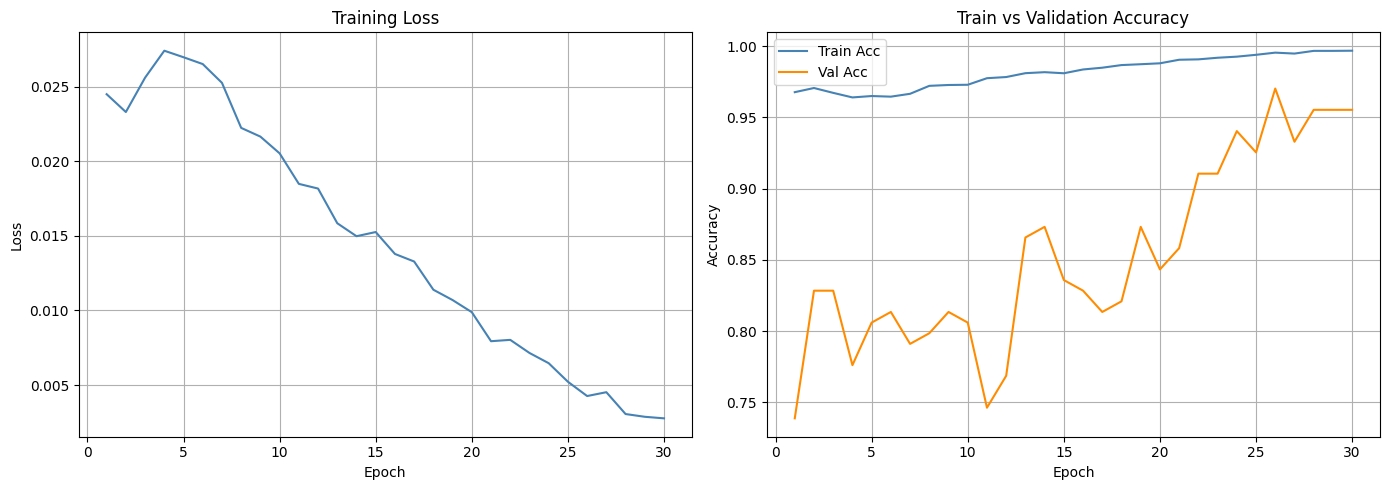

Plot saved.


In [24]:
epochs_range = range(1, len(history['train_loss']) + 1)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(epochs_range, history['train_loss'], color='steelblue')
ax1.set_xlabel('Epoch'); ax1.set_ylabel('Loss')
ax1.set_title('Training Loss'); ax1.grid(True)

ax2.plot(epochs_range, history['train_acc'], label='Train Acc', color='steelblue')
ax2.plot(epochs_range, history['val_acc'], label='Val Acc', color='darkorange')
ax2.set_xlabel('Epoch'); ax2.set_ylabel('Accuracy')
ax2.set_title('Train vs Validation Accuracy')
ax2.legend(); ax2.grid(True)

plt.tight_layout()
plt.savefig(os.path.join(CUR_DIR, 'b23bb1004_curves.png'), dpi=100, bbox_inches='tight')
plt.show()
print('Plot saved.')


## Cell 8 — Grad-CAM Visualization

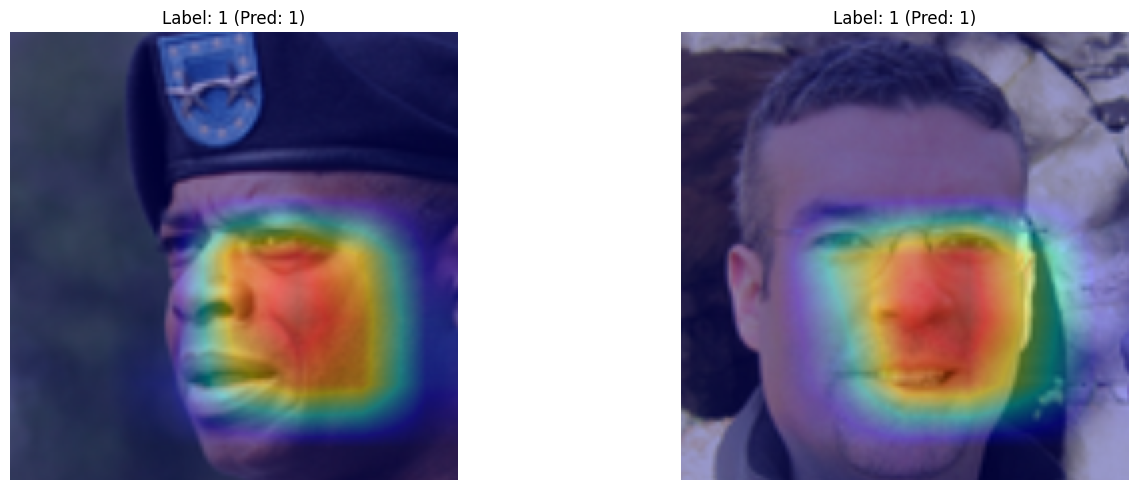

: 

In [ ]:
import cv2
from PIL import Image

class GradCAM:
    def __init__(self, model, target_layer):
        self.model = model
        self.target_layer = target_layer
        self.gradients = None
        self.activations = None
        self.hook_layers()

    def hook_layers(self):
        def forward_hook(module, input, output):
            self.activations = output.detach()
        def backward_hook(module, grad_input, grad_output):
            self.gradients = grad_output[0].detach()

        self.target_layer.register_forward_hook(forward_hook)
        self.target_layer.register_full_backward_hook(backward_hook)

    def generate_heatmap(self, input_tensor, class_idx=None):
        self.model.eval()
        output = self.model(input_tensor)
        if class_idx is None:
            class_idx = output.argmax(dim=1).item()

        self.model.zero_grad()
        output[0, class_idx].backward()

        weights = torch.mean(self.gradients, dim=(2, 3), keepdim=True)
        heatmap = torch.sum(weights * self.activations, dim=1).squeeze()
        heatmap = np.maximum(heatmap.cpu().numpy(), 0)
        heatmap /= np.max(heatmap) if np.max(heatmap) > 0 else 1
        return heatmap

def show_gradcam(model, dataset, indices, device):
    target_layer = model.layer4[-1] # Last conv layer of ResNet-18
    cam = GradCAM(model, target_layer)
    
    plt.figure(figsize=(15, 5))
    for i, idx in enumerate(indices):
        img_tensor, label = dataset[idx]
        input_tensor = img_tensor.unsqueeze(0).to(device)
        
        heatmap = cam.generate_heatmap(input_tensor)
        
        # Denormalize image for display
        img_show = img_tensor.permute(1, 2, 0).numpy()
        img_show = img_show * np.array([0.229, 0.224, 0.225]) + np.array([0.485, 0.456, 0.406])
        img_show = np.clip(img_show, 0, 1)
        
        heatmap_resized = cv2.resize(heatmap, (IMG_SIZE, IMG_SIZE))
        heatmap_color = cv2.applyColorMap(np.uint8(255 * heatmap_resized), cv2.COLORMAP_JET)
        heatmap_color = cv2.cvtColor(heatmap_color, cv2.COLOR_BGR2RGB) / 255.0
        
        result = 0.6 * img_show + 0.4 * heatmap_color
        
        plt.subplot(1, len(indices), i+1)
        plt.imshow(result)
        plt.title(f'Label: {label} (Pred: {model(input_tensor).argmax(1).item()})')
        plt.axis('off')
    plt.tight_layout()
    plt.show()

# Usage Example (Index 0 and 10 from val set)
v_set_orig = ValidDataset(VALID_DIR, VALID_LABELS, transform=val_transform)
show_gradcam(model, v_set_orig, [0, 10], DEVICE)


## Cell 9 — PCA Plot of Validation Features

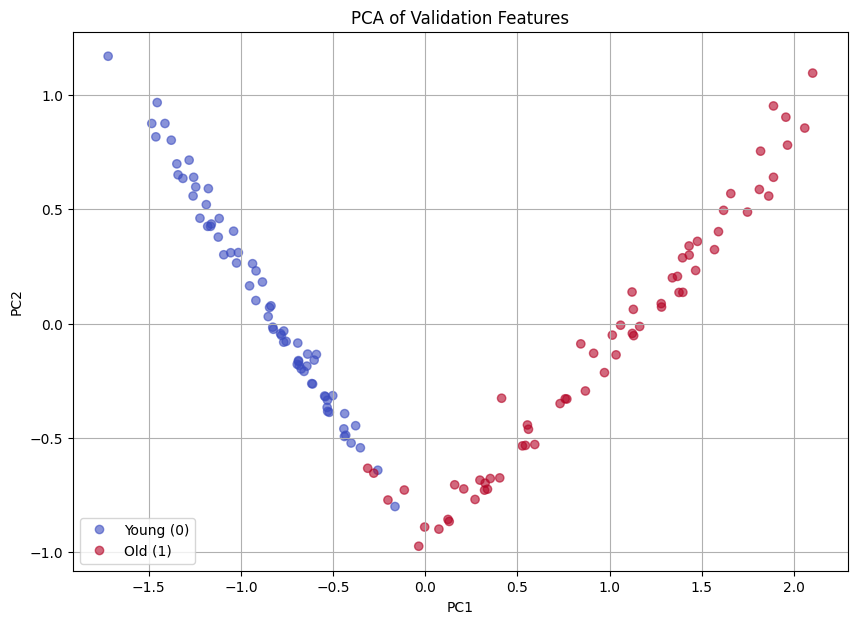

In [26]:
from sklearn.decomposition import PCA

def plot_pca(model, loader, device):
    model.eval()
    features = []
    labels = []
    
    # Hook to get features before FC layer
    feat_list = []
    def hook(module, input, output):
        feat_list.append(output.detach().cpu().squeeze())
    
    handle = model.avgpool.register_forward_hook(hook)
    
    with torch.no_grad():
        for imgs, lbls in loader:
            imgs = imgs.to(device)
            model(imgs)
            labels.extend(lbls.numpy())
    
    handle.remove()
    features = torch.cat(feat_list, dim=0).numpy()
    
    pca = PCA(n_components=2)
    feat_2d = pca.fit_transform(features)
    
    plt.figure(figsize=(10, 7))
    scatter = plt.scatter(feat_2d[:, 0], feat_2d[:, 1], c=labels, cmap='coolwarm', alpha=0.6)
    plt.legend(handles=scatter.legend_elements()[0], labels=['Young (0)', 'Old (1)'])
    plt.title('PCA of Validation Features')
    plt.xlabel('PC1'); plt.ylabel('PC2'); plt.grid(True)
    plt.show()

v_loader_pca = DataLoader(v_set_orig, batch_size=BATCH_SIZE, shuffle=False)
plot_pca(model, v_loader_pca, DEVICE)
